<a href="https://colab.research.google.com/github/KU-BIG/KUBIG_2026_SPRING/blob/main/Basic%20Study/ML/6%EC%A3%BC%EC%B0%A8/2026_1_ML_week6_%EC%9C%A4%EC%A7%80%EC%9B%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 (Tree-based Models)

## 2.1. Decision Tree

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [3]:
# 데이터 로드 및 전처리
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# 훈련/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Q1.1 max_depth 파라미터를 변경하면 트리의 구조와 성능이 어떻게 변할까요?

- max_depth 는 의사결정트리의 최대 깊이를 제한하는 하이퍼파라미터.
- max_depth 작게 설정: 트리가 얕음, 학습 데이터에서 단순한 규칙만 학습. 따라서 underfitting 가능성이 높음
- max_depth 깊게 설정: 트리가 깊어짐, 학습 데이터에 있는 세부 패턴까지 학습. 따라서 overfitting 가능성이 높아짐.

In [4]:
# 결정 트리 모델 생성 및 학습
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=42)

### Q1.2 'gini'와 'entropy' 기준의 차이는 무엇이며, 결과에 어떤 영향을 미칠까요?

gini와 entropy는 트리가 분할(split)할 때 노드를 평가하는 방식에 차이가 있음.
- gini impurity: 노드가 얼마나 순수한가, 불순도를 평가 기준으로. 이에 노드를 균등하게 나누는 경향이 있음. 따라서 더 균형잡힌 가지.
- entropy: 분할을 통해 얻는 정보가 얼마나 많은가를 기준으로. 이에 노드에서 정보 이득 기준으로 더 보수적으로 분할.

큰 데이터에서 지니인덱스가 단순 계산을 기반으로 하기에 좀 더 빠르다는 특징이 있지만, 최종 정확도/성능은 거의 비슷함.

In [6]:
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, random_state=42)

In [5]:
tree_model = DecisionTreeClassifier(criterion="entropy", max_depth=3, min_samples_leaf=2, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=2,
                       random_state=42)

### Q1.3 각 노드의 분할 기준 어떻게 되는지 설명해보세요.

- 루트 노드: petal length ≤ 2.45 cm
- 왼쪽 자식 노드: gini=0, 더 이상 분할 필요 없음
- 오른쪽 자식 노드: petal length ≤ 4.75
- 왼족 하위 노드: petal width ≤ 1.55
- 오른쪽 하위 노드: petal width ≤ 1.75


In [7]:
# 트리 시각화 (Graphviz)
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

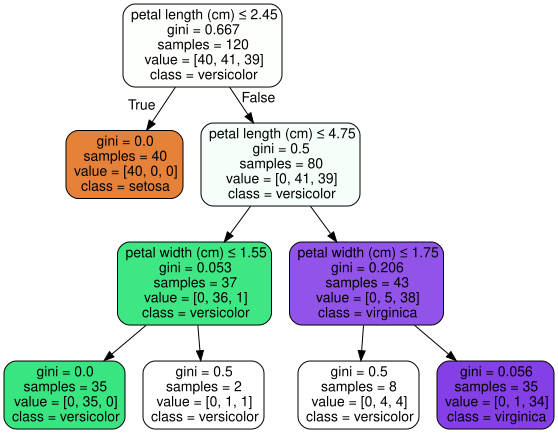

In [8]:
# 그래프 출력
graph = graphviz.Source(dot_data)
graph

## 3. 앙상블 학습: 부스팅(Boosting) 모델

Adaboost, Gradient Boosting Model은 scikit learn에서 지원하지만, LightGBM과 XGBoost의 경우는 외부 패키지를 불러와야 합니다.

Boosting 계열의 모델들은 데이터 개수가 적으면 overfitting이 일어나는 경우가 많으니, 주의해야 합니다.

In [9]:
# 필요한 패키지 로드
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()

In [10]:
# 데이터 로드
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['MedHouseVal'] = housing.target

In [11]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Q3.1 `housing_df`를 train, test split을 해봅시다.

분할 비율을 자유롭게 설정해봅시다.

In [12]:
# 데이터 분할
X = housing_df.drop(columns=['MedHouseVal'])
y = housing_df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3 , random_state=42)

### Q3.2  데이터를 `RandomForestRegressor`에 적합해 봅시다.
train set 에 대해 `MedHouseVal`을 종속변수, 나머지를 독립변수로 하는 random forest regressor를 적합해 봅시다.

test set으로 prediction을 한 후 MSE를 구해 봅시다.

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 모델 생성 및 학습
rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

# 예측 및 평가
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
print(f"Random Forest MSE: {rf_mse:.4f}")

Random Forest MSE: 0.2565


RandomForestRegressor 의 원리
- Bootstrap (중복허용샘플링)
- Random Feature Selection: 변수 중 일부만 무작위로 후보로 선정, 그 중 최선을 찾음.

In [ ]:
#RaondomForestRegressor 구현 from scratch
import numpy as np

class RandomForestFromScratch:
    def __init__(self, n_estimators=10, max_depth=5, min_samples_split=2, max_features=None):
        self.n_estimators = n_estimators #Bootstrap으로 트리를 몇개 만들 것인지 결정
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features #트리가 분할될 때 전체 피처 중 몇개를 후보로 쓸지 결정
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            # 1. Bootstrapping: 데이터 복원 추출
            idx = np.random.choice(len(X), size=len(X), replace=True)
            X_sample, y_sample = X.iloc[idx], y.iloc[idx]

            # 2. 개별 결정 트리 학습 (scikit-learn의 DecisionTreeRegressor 구조 모방)
            # RandomForest 는 개별 트리의 학습 방식이 아닌, 여러개의 트리의 예측값을 Aggregating하는 모델
            from sklearn.tree import DecisionTreeRegressor
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features  # Feature Subsampling 핵심!
            )
            #트리가 노드를 나눌 때마다 모든 변수를 검사하지 않고 max_feature개수만큼 무작위로
            #변수를 무작위로 제한하여 트리 간의 상관관계를 낮추는 것.
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        # 3. Aggregation: 모든 트리의 예측값 평균
        # BAGGING: Bootstrap Aggregating
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(tree_preds, axis=0)

### Q3.3 데이터를 `AdaBoostRegressor`에 적합해봅시다.

위와 동일

In [15]:
from sklearn.ensemble import AdaBoostRegressor

ada_model = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)
ada_mse = mean_squared_error(y_test, ada_pred)
print(f"AdaBoost MSE: {ada_mse:.4f}")

AdaBoost MSE: 0.7592


### Q3.4 데이터를 `GradientBoostingRegressor`에 적합해 봅시다.

위와 동일

In [16]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_pred)
print(f"Gradient Boosting MSE: {gb_mse:.4f}")

Gradient Boosting MSE: 0.2884


### Q3.5 데이터를 `lightgbm` 회귀에 적합해 봅시다.

파라미터를 자세히 살펴보고, 자유롭게 설정해 봅시다.

Documentation
https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

예시
https://www.geeksforgeeks.org/regression-using-lightgbm/


In [18]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=500,        # 반복 횟수 (충분히 학습하도록 설정)
    learning_rate=0.05,      # 학습률 (조금 더 세밀하게 접근)
    num_leaves=40,           # 트리의 복잡도 조절
    min_child_samples=25,    # 과적합 방지용 노드 내 최소 데이터 수
    max_depth=-1,            # 트리의 깊이 제한 없음 (num_leaves로 조절)
    feature_fraction=0.8,    # 트리 구성 시 선택할 피처 비율 (80%)
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)
lgbm_mse = mean_squared_error(y_test, lgbm_pred)
print(f"LightGBM MSE: {lgbm_mse:.4f}")

LightGBM MSE: 0.1888


### Q3.6 데이터를 `xgboost`에 적합해 봅시다.

파라미터는 자유롭게 설정해 봅시다

In [17]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_mse = mean_squared_error(y_test, xgb_pred)
print(f"XGBoost MSE: {xgb_mse:.4f}")

XGBoost MSE: 0.2267


XGBoost: 이전 트리가 틀린 만큼을 다음 트리가 메꾸는 방식.
- 2차 미분 활용: 어느 방향으로 틀렸는지(1차미분) + 얼마나 급격하게 변하는지
- 정규화: 과적합 방지, 모델이 복잡해지면 스스로 벌점을 줌.

In [ ]:
import numpy as np

class XGBoostFromScratch:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=3, reg_lambda=1.0):
        self.n_estimators = n_estimators
        self.lr = learning_rate
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda # L2 Regularization
        self.trees = []
        self.base_pred = None

    def fit(self, X, y):
        # 1. 초기값 설정 (평균값으로 시작)
        self.base_pred = np.mean(y)
        f_m = np.full(len(y), self.base_pred)

        for _ in range(self.n_estimators):
            # 2. Gradient(g)와 Hessian(h) 계산 (MSE 손실 함수 기준)
            # MSE: (y - y_hat)^2 -> g = -2(y - y_hat), h = 2
            g = -2 * (y - f_m) #gradient 계산: 예측값과 실제값 얼마나 차이 나는지 1차 미분값
            h = np.full(len(y), 2.0) #hessian: 손실함수가 얼마나 급격하게 변하는지 2차 미분값

            # 3. g와 h를 타겟으로 하는 트리 학습 (구조적 손실 최소화)
            from sklearn.tree import DecisionTreeRegressor
            tree = DecisionTreeRegressor(max_depth=self.max_depth)
            # 트리의 각 리프 노드 가중치 w = -sum(g) / (sum(h) + lambda) 계산 로직이 핵심
            # 모델이 실제 집값(y)를 학습하는 것이 아닌, 앞서 트리가 남긴 오차를 학습하는 구조임.
            # self.reg_lambda는 벌점, 모델 과적합 방지
            tree.fit(X, -g / (h + self.reg_lambda))

            # 4. 모델 업데이트 (Learning Rate 적용)
            # 새트리가 찾은 예측값 그대로 다 더하지 ㅇ낳고, 학습률을 곱해서 조금씩만 반영.
            f_m += self.lr * tree.predict(X)
            self.trees.append(tree)

    def predict(self, X):
        y_pred = np.full(len(X), self.base_pred)
        for tree in self.trees:
            y_pred += self.lr * tree.predict(X)
        return y_pred

### Q3.7 `RandomForestRegressor`의 feature importance를 시각화해봅시다.

https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html

위를 참고해보면서 Q2에서 적합한 random forest regressor의 feature importance를 시각화해 봅시다.

중요한 feature 부터 내림차순으로 시각화해 봅시다.

/tmp/ipython-input-1550363776.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma')


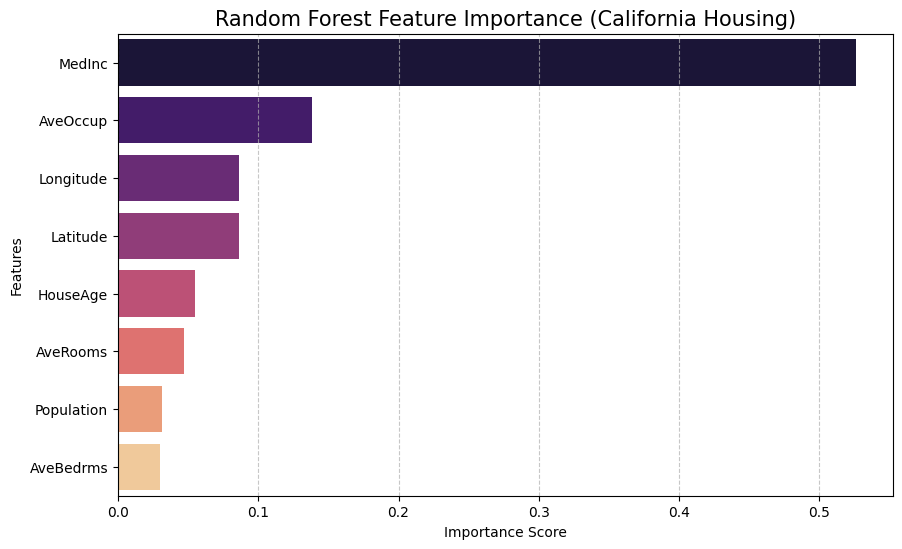

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 특성 중요도 추출 및 데이터프레임 변환
importances = rf_model.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. 중요도 순으로 내림차순 정렬
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 3. 시각화 설정
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma')

# 차트 제목 및 레이블 설정
plt.title('Random Forest Feature Importance (California Housing)', fontsize=15)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


### (BONUS) 1. Boosting 모델 각각의 특징을 정리해보시오

Boosting: 기존 모델이 틀린 샘플에 대해 더 많은 가중치를 부여하며 학습하는 기법(오답노트)

핵심최적화방식에 따른 분류.
- AdaBoost: 이전 트리가 틀린 샘플에 대해 가중치 높임
- GBM: 오차를 최소화하는 방향으로 다음 트리 학습. 가중치 대신 경사하강법 도입
- XGBoost: 2차 미분 활용, 정규화 활용(과적합 방지)
- LightGBM: 리프중심분할. 오차를 가장 많이 줄일 수 있는 리프 노드를 찾아 수직으로 깊게 키움.

### (BONUS) 2. 모델 성능을 높이기 위하여 어떤 시도를 하면 좋을지 고민해보세요.